In [10]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import pyvinecopulib as pv
import seaborn as sns
import matplotlib.pyplot as plt

import json

In [11]:
# Read game inputs
with open('../tests_support2_small/inference/runconfig.json') as file:
        runconfig = json.load(file)

# Read regression coefficients from AIA game
regCoeff = pd.read_csv("../tests_support2_small/inference/reg_coeff_dict_keys(['totcst', 'crea']).csv")

# Parameters
d = regCoeff.shape[1] - 3
nIter = runconfig['nIter']
nSynT = runconfig['nSynT']


In [12]:
regCoeff.columns # d regression coefficients per game and each synthetic data set per game (and for each combination of  sensitive attribute, target ID and genModel)

Index(['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9', 'b10',
       'b11', 'b12', 'b13', 'b14', 'b15', 'b16', 'b17', 'b18', 'b19', 'b20',
       'b21', 'b22', 'b23', 'b24', 'b25', 'b26', 'sa', 'tid', 'genModel'],
      dtype='object')

In [13]:
regCoeff.sa.unique(), regCoeff.tid.unique(), regCoeff.genModel.unique()

(array(['totcst', 'crea'], dtype=object),
 array(['ID84', 'ID447'], dtype=object),
 array(['IMRV(weight=0.25, trunc_lvl=26)',
        'IMRV(weight=0.5, trunc_lvl=26)',
        'IMRV(weight=0.75, trunc_lvl=26)',
        'CvineSensitive(lmbda=5, trunc_lvl=26)', 'Cvine(trunc_lvl=1)',
        'Cvine(trunc_lvl=5)', 'Cvine(trunc_lvl=10)', 'Cvine(trunc_lvl=15)',
        'Cvine(trunc_lvl=20)', 'Cvine(trunc_lvl=26)',
        'PrivBayes(epsilon=0.1)', 'CTGAN(epochs=400, batch_size=100)',
        'TVAE(epochs=800, batch_size=100)'], dtype=object))

In [14]:
sa = "totcst"
tid = "ID84"
MAB = []
for gm in regCoeff.genModel.unique():
    print(gm)
    df = regCoeff.loc[(regCoeff["sa"]==sa) & (regCoeff["tid"] == tid) & (regCoeff["genModel"]==gm),]
    mab = df[df.columns[range(d)]].abs().sum().sum()/(d*df.shape[0])
    MAB.append(mab)

IMRV(weight=0.25, trunc_lvl=26)
IMRV(weight=0.5, trunc_lvl=26)
IMRV(weight=0.75, trunc_lvl=26)
CvineSensitive(lmbda=5, trunc_lvl=26)
Cvine(trunc_lvl=1)
Cvine(trunc_lvl=5)
Cvine(trunc_lvl=10)
Cvine(trunc_lvl=15)
Cvine(trunc_lvl=20)
Cvine(trunc_lvl=26)
PrivBayes(epsilon=0.1)
CTGAN(epochs=400, batch_size=100)
TVAE(epochs=800, batch_size=100)


Text(0, 0.5, 'MAB_totcst')

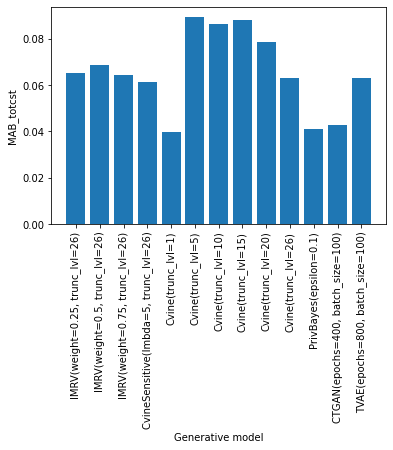

In [15]:
plt.bar(regCoeff.genModel.unique(), MAB)
plt.xticks(rotation=90)
plt.xlabel("Generative model")
plt.ylabel(rf"MAB_{sa}")

In [16]:
coefficients = [f"b{i}" for i in range(d)]
MAB = regCoeff.groupby(['sa', 'tid', 'genModel'])[coefficients].apply(lambda x: x.abs().to_numpy().sum()/(d*nIter*nSynT))

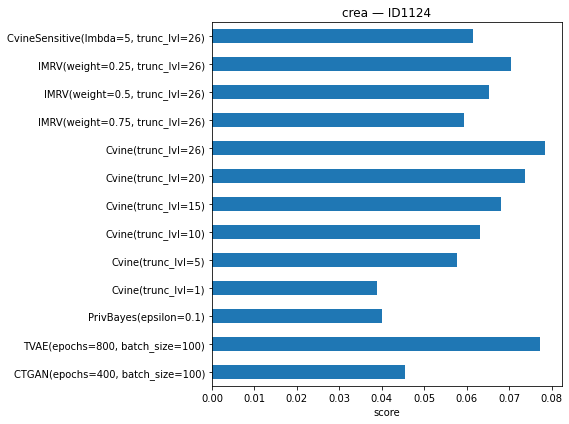

In [17]:
sub = MAB.loc[("crea", "ID84")]
order = [
    'CTGAN(epochs=400, batch_size=100)',
    'TVAE(epochs=800, batch_size=100)', 
    'PrivBayes(epsilon=0.1)',
    'Cvine(trunc_lvl=1)',
    'Cvine(trunc_lvl=5)',
    'Cvine(trunc_lvl=10)',
    'Cvine(trunc_lvl=15)', 
    'Cvine(trunc_lvl=20)',
    'Cvine(trunc_lvl=26)', 
    'IMRV(weight=0.75, trunc_lvl=26)',
    'IMRV(weight=0.5, trunc_lvl=26)',
    'IMRV(weight=0.25, trunc_lvl=26)', 
    'CvineSensitive(lmbda=5, trunc_lvl=26)',
]
sub = sub.reindex(order)
ax = sub.plot.barh(figsize=(8, 6))
ax.set_xlabel("score")
ax.set_ylabel("")
ax.set_title("crea — ID1124")
plt.tight_layout()
plt.show()